In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../data/processed_data.csv')
print(df.shape)
df.head()

(425, 16)


,Date,Country,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee type,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear,Season
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,53,Summer
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,53,Summer
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,1,Summer
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,2016,1,8,Friday,1,Summer
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,2016,1,10,Sunday,1,Summer


In [4]:
target_col = None

for col in df.columns:
    if 'accident' in col.lower() and 'level' in col.lower():
        target_col = col

print("Target column:", target_col)

Target column: Potential Accident Level


In [5]:
text_cols = [col for col in df.columns if 'desc' in col.lower()]
df = df.drop(columns=text_cols)

print("Columns used:", df.columns)

Columns used: Index(['Date', 'Country', 'Local', 'Industry Sector', 'Accident Level',
       'Potential Accident Level', 'Gender', 'Employee type', 'Critical Risk',
       'Year', 'Month', 'Day', 'Weekday', 'WeekofYear', 'Season'],
      dtype='str')


In [6]:
# Handling Missing Values
print(df.isnull().sum())
df = df.dropna()

Date                        0
Country                     0
Local                       0
Industry Sector             0
Accident Level              0
Potential Accident Level    0
Gender                      0
Employee type               0
Critical Risk               0
Year                        0
Month                       0
Day                         0
Weekday                     0
WeekofYear                  0
Season                      0
dtype: int64


In [ ]:
# Encode Target
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

y = df[target_col]

In [8]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col != target_col]

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != target_col]

# One-hot encoding
X_cat = pd.get_dummies(df[categorical_cols], drop_first=True)

# Combine
X = pd.concat([X_cat, df[numerical_cols]], axis=1)

print("Feature shape:", X.shape)

Feature shape: (425, 353)


In [9]:
# Remove rare classes BEFORE feature creation
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index

mask = y.isin(valid_classes)

X = X[mask]
y = y[mask]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Scale Feature (Important for Logistic Regression)
scaler = StandardScaler(with_mean=False)  # works with sparse data

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# RQ1: Ensemble Machine Learning Models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier()
}

In [13]:
# Train and Evaluate
results = []

for name, model in models.items():
    
    # Use scaled data only for Logistic Regression
    if name == "LogisticRegression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print(classification_report(y_test, y_pred))
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })


===== LogisticRegression =====
Accuracy: 0.4823529411764706
F1 Score: 0.48478164790066297
              precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       0.41      0.37      0.39        19
           2       0.32      0.33      0.33        21
           3       0.55      0.59      0.57        29
           4       0.43      0.50      0.46         6

    accuracy                           0.48        85
   macro avg       0.52      0.50      0.50        85
weighted avg       0.49      0.48      0.48        85


===== RandomForest =====
Accuracy: 0.5058823529411764
F1 Score: 0.5052100840336134
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.39      0.47      0.43        19
           2       0.21      0.19      0.20        21
           3       0.66      0.66      0.66        29
           4       0.75      0.50      0.60         6

    accura

In [14]:
# Final Comparison Table 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\n===== FINAL MODEL COMPARISON =====")
print(results_df)


===== FINAL MODEL COMPARISON =====
                Model  Accuracy  F1 Score
2    GradientBoosting  0.541176  0.531107
1        RandomForest  0.505882  0.505210
0  LogisticRegression  0.482353  0.484782


### 🚀 ✅ 1. Feature Importance (Structured Models)
#### 📊 Random Forest Feature Importance

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names
feature_names = X.columns

# Train model (if not already trained)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Extract importance
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

# Top 15 features
top_rf = rf_importance.head(15)

print(top_rf)

                       Feature  Importance
352                 WeekofYear    0.073433
351                        Day    0.069800
350                      Month    0.051364
302         Accident Level_III    0.024426
306  Employee type_Third Party    0.021338
299     Industry Sector_Mining    0.021315
300     Industry Sector_Others    0.021178
289             Local_Local_03    0.020695
303          Accident Level_IV    0.018711
287         Country_Country_03    0.018369
323       Critical Risk_Others    0.017414
296             Local_Local_10    0.016840
349                       Year    0.016522
343           Weekday_Thursday    0.016259
286         Country_Country_02    0.016049


#### 📊 Gradient Boosting Feature Importance

In [16]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

gb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(by='Importance', ascending=False)

top_gb = gb_importance.head(15)

print(top_gb)

                                         Feature  Importance
302                           Accident Level_III    0.059151
296                               Local_Local_10    0.051574
303                            Accident Level_IV    0.039530
287                           Country_Country_03    0.038839
352                                   WeekofYear    0.036054
304                             Accident Level_V    0.035412
351                                          Day    0.028318
305                                  Gender_Male    0.024823
300                       Industry Sector_Others    0.021166
41                               Date_2016-03-11    0.018385
299                       Industry Sector_Mining    0.014639
289                               Local_Local_03    0.013356
56                               Date_2016-04-03    0.012401
317                Critical Risk_Fall prevention    0.011009
337  Critical Risk_Vehicles and Mobile Equipment    0.010789


### 📈 ✅ 2. Feature Importance Plot (Paper-Ready)
#### Random Forest Plot

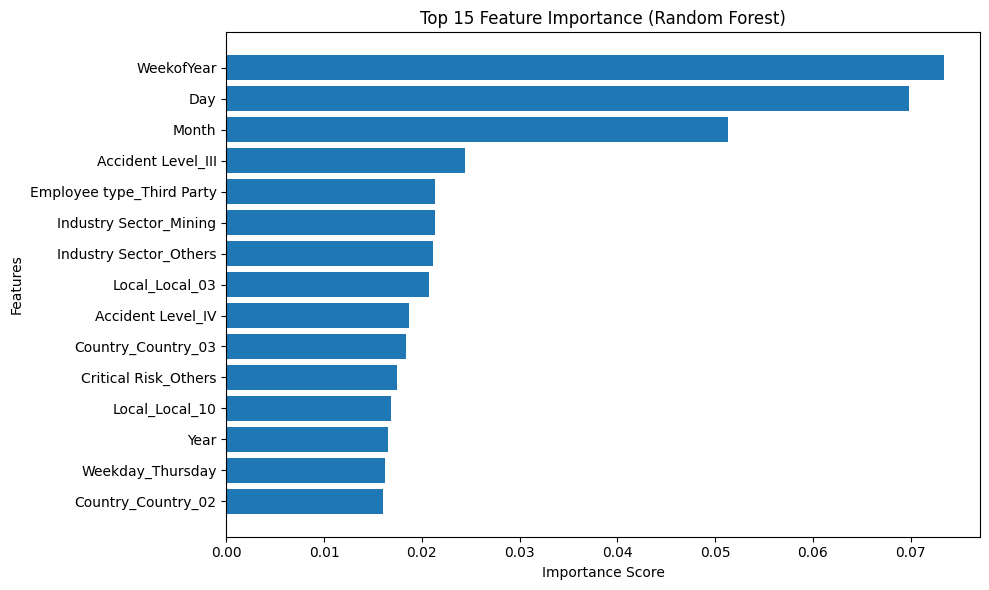

In [17]:
plt.figure(figsize=(10,6))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

#### Gradient Boosting Plot

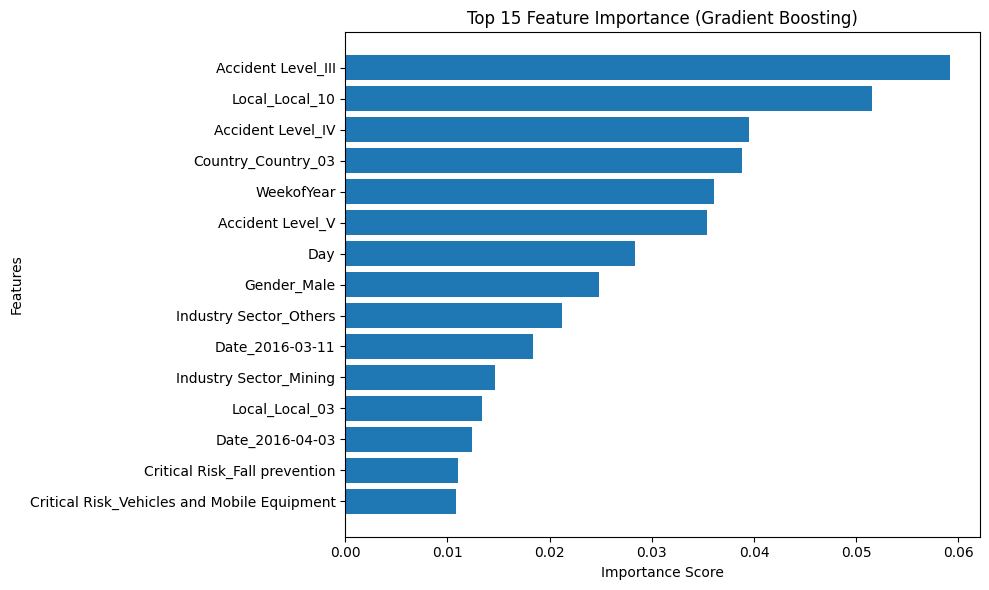

In [18]:
plt.figure(figsize=(10,6))
plt.barh(top_gb['Feature'], top_gb['Importance'])
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### 📊 ✅ 3. Model Comparison Plot (VERY IMPORTANT for paper)

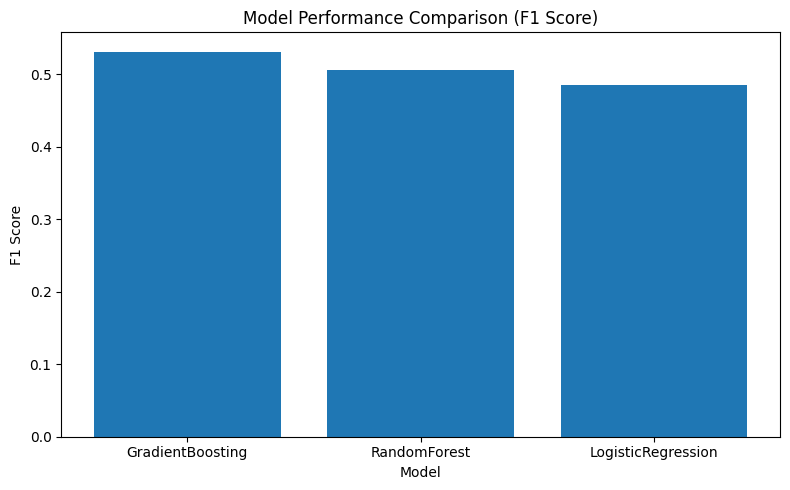

In [19]:
# results_df already created earlier

plt.figure(figsize=(8,5))

plt.bar(results_df['Model'], results_df['F1 Score'])
plt.title("Model Performance Comparison (F1 Score)")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.show()

#### 📊 Optional: Accuracy Plot

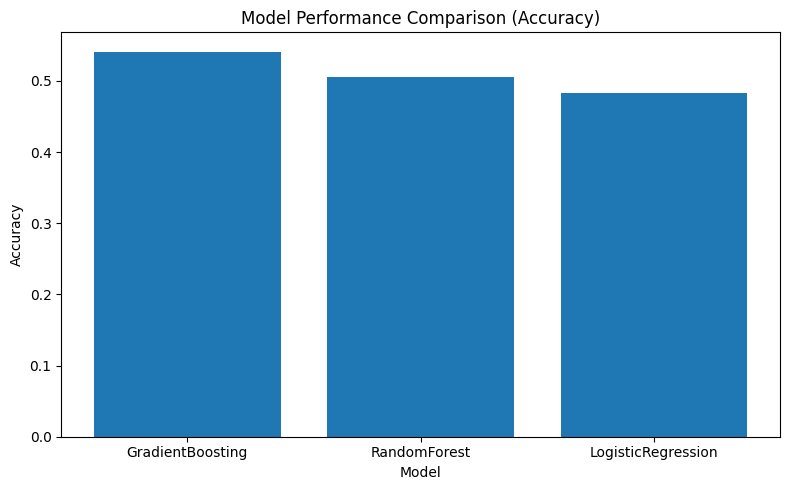

In [20]:
plt.figure(figsize=(8,5))

plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Performance Comparison (Accuracy)")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

### 🚀 ✅ RQ2 FINAL CODE (STRUCTURED + TEXT FEATURES)

#### 1. Import all required Libraries

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scipy.sparse import hstack

import warnings
warnings.filterwarnings("ignore")

#### 📂 2. Load Data

In [27]:
df = pd.read_csv("../data/processed_data.csv")
print(df.shape)

(425, 16)


### 🧠 3. Identify Columns

In [28]:
text_col = None
target_col = None

for col in df.columns:
    if 'desc' in col.lower():
        text_col = col
    if 'accident' in col.lower() and 'level' in col.lower():
        target_col = col

print("Text:", text_col)
print("Target:", target_col)

Text: Description
Target: Potential Accident Level


#### 🧹 4. Clean Data

In [29]:
df = df.dropna(subset=[text_col, target_col]).reset_index(drop=True)

# Encode target
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

y = df[target_col]

#### ⚠️ 5. Remove Rare Classes

In [30]:
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index

df = df[df[target_col].isin(valid_classes)].reset_index(drop=True)
y = df[target_col]

#### 📊 6. Structured Features (Same as RQ1)

In [31]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in [text_col]]

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != target_col]

X_cat = pd.get_dummies(df[categorical_cols], drop_first=True)

X_struct = pd.concat([X_cat, df[numerical_cols]], axis=1)

##### Step 1: Ensure all columns are numeric

In [41]:
from scipy.sparse import csr_matrix
X_struct = X_struct.apply(pd.to_numeric, errors='coerce')
X_struct = X_struct.fillna(0)
X_struct = X_struct.astype(np.float32)
X_struct_sparse = csr_matrix(X_struct)

##### Step 2: Convert to sparse matrix

#### 🔤 7. TEXT FEATURES

##### ✅ TFIDF

In [32]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_tfidf = tfidf.fit_transform(df[text_col])

##### ✅ Bag of Words

In [33]:
bow = CountVectorizer(max_features=5000, stop_words='english')

X_bow = bow.fit_transform(df[text_col])

#### 🔗 8. COMBINE FEATURES (Hybrid)

##### 🔥 Structured + TF-IDF

In [42]:
X_combined_tfidf = hstack([X_struct, X_tfidf])

##### 🔥 Structured + BoW

In [43]:
X_combined_bow = hstack([X_struct, X_bow])

#### ✂️ 9. Train-Test Split

In [44]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_combined_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train_bow, X_test_bow, _, _ = train_test_split(
    X_combined_bow, y, test_size=0.2, random_state=42, stratify=y
)

#### ⚖️ 10. Scaling (for Logistic Regression only)

In [45]:
scaler = StandardScaler(with_mean=False)

X_train_tfidf_scaled = scaler.fit_transform(X_train_tfidf)
X_test_tfidf_scaled = scaler.transform(X_test_tfidf)

X_train_bow_scaled = scaler.fit_transform(X_train_bow)
X_test_bow_scaled = scaler.transform(X_test_bow)

#### 🤖 11. Models

In [46]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier()
}

#### 📊 12. Evaluation Function

In [47]:
def evaluate(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    return acc, f1

#### 🚀 13. Run RQ2 Experiments

In [48]:
results_rq2 = []

# TF-IDF
for name, model in models.items():
    
    if name == "LogisticRegression":
        acc, f1 = evaluate(model, X_train_tfidf_scaled, X_test_tfidf_scaled, y_train, y_test, name)
    else:
        acc, f1 = evaluate(model, X_train_tfidf, X_test_tfidf, y_train, y_test, name)
    
    results_rq2.append({
        "Model": name,
        "Data": "Structured + TF-IDF",
        "Accuracy": acc,
        "F1 Score": f1
    })


# BoW
for name, model in models.items():
    
    if name == "LogisticRegression":
        acc, f1 = evaluate(model, X_train_bow_scaled, X_test_bow_scaled, y_train, y_test, name)
    else:
        acc, f1 = evaluate(model, X_train_bow, X_test_bow, y_train, y_test, name)
    
    results_rq2.append({
        "Model": name,
        "Data": "Structured + BoW",
        "Accuracy": acc,
        "F1 Score": f1
    })

#### 📈 14. Final Comparison Table (RQ1 vs RQ2)

In [49]:
results_rq2_df = pd.DataFrame(results_rq2)

print("\n===== RQ2 RESULTS =====")
print(results_rq2_df.sort_values(by="F1 Score", ascending=False))


===== RQ2 RESULTS =====
                Model                 Data  Accuracy  F1 Score
4        RandomForest     Structured + BoW  0.611765  0.606303
5    GradientBoosting     Structured + BoW  0.588235  0.579884
1        RandomForest  Structured + TF-IDF  0.541176  0.523767
2    GradientBoosting  Structured + TF-IDF  0.529412  0.518882
3  LogisticRegression     Structured + BoW  0.423529  0.434690
0  LogisticRegression  Structured + TF-IDF  0.388235  0.392302


### RQ3 - Traditional LSTM model, BiLSTM and Stacked LSTM

#### 📦 1. Imports Required Libaries

In [50]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#### 📂 2. Load + Prepare Data

In [51]:
df = pd.read_csv("../data/processed_data.csv")
print(df.shape)
# Identify columns
text_col = [c for c in df.columns if 'desc' in c.lower()][0]
target_col = [c for c in df.columns if 'accident' in c.lower() and 'level' in c.lower()][0]

df = df.dropna(subset=[text_col, target_col]).reset_index(drop=True)

# Encode target
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
y = df[target_col]

(425, 16)


#### 🔤 3. Tokenization

In [52]:
MAX_WORDS = 20000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df[text_col])

X_seq = tokenizer.texts_to_sequences(df[text_col])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

#### ⚖️ 4. Class Weights (CRITICAL)

In [53]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

#### ⚙️ 5. Callbacks

In [54]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-5
)

#### 🧠 6. Model Builder (Flexible)

In [55]:
def build_model(model_type, lstm_units=128, dropout_rate=0.3, lr=0.001):
    
    model = Sequential()
    
    model.add(Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN))
    
    if model_type == "vanilla":
        model.add(LSTM(lstm_units))
        
    elif model_type == "bilstm":
        model.add(Bidirectional(LSTM(lstm_units)))
        
    elif model_type == "stacked":
        model.add(LSTM(lstm_units, return_sequences=True))
        model.add(LSTM(lstm_units//2))
    
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(len(np.unique(y)), activation='softmax'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    
    return model

#### 🔥 7. Hyperparameter Grid

In [56]:
param_grid = {
    "lstm_units": [64, 128],
    "dropout_rate": [0.3, 0.5],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [10, 15]
}

#### 🚀 8. Training Loop (ALL MODELS)

In [57]:
results = []

model_types = ["vanilla", "bilstm", "stacked"]

for model_type in model_types:
    
    for units in param_grid["lstm_units"]:
        for dropout in param_grid["dropout_rate"]:
            for lr in param_grid["learning_rate"]:
                for batch in param_grid["batch_size"]:
                    for epochs in param_grid["epochs"]:
                        
                        print(f"\nRunning: {model_type}, units={units}, dropout={dropout}, lr={lr}")
                        
                        model = build_model(model_type, units, dropout, lr)
                        
                        history = model.fit(
                            X_train, y_train,
                            validation_split=0.2,
                            epochs=epochs,
                            batch_size=batch,
                            class_weight=class_weights,
                            callbacks=[early_stop, lr_reduce],
                            verbose=0
                        )
                        
                        # Evaluate
                        y_pred = np.argmax(model.predict(X_test), axis=1)
                        
                        acc = accuracy_score(y_test, y_pred)
                        f1 = f1_score(y_test, y_pred, average='weighted')
                        
                        results.append({
                            "Model": model_type,
                            "Units": units,
                            "Dropout": dropout,
                            "LR": lr,
                            "Batch": batch,
                            "Epochs": epochs,
                            "Accuracy": acc,
                            "F1 Score": f1
                        })


Running: vanilla, units=64, dropout=0.3, lr=0.001
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Running: vanilla, units=64, dropout=0.3, lr=0.001
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Running: vanilla, units=64, dropout=0.3, lr=0.001
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x1274051c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━

#### 📊 9. Results Table (Paper-Ready)

In [58]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df.head(10))

      Model  Units  Dropout      LR  Batch  Epochs  Accuracy  F1 Score
11  vanilla     64      0.5  0.0010     64      15  0.752941  0.655462
94  stacked    128      0.5  0.0005     64      10  0.752941  0.655462
64  stacked     64      0.3  0.0010     32      10  0.752941  0.655462
21  vanilla    128      0.3  0.0005     32      15  0.741176  0.649660
69  stacked     64      0.3  0.0005     32      15  0.741176  0.649660
93  stacked    128      0.5  0.0005     32      15  0.729412  0.643779
82  stacked    128      0.3  0.0010     64      10  0.729412  0.642059
9   vanilla     64      0.5  0.0010     32      15  0.729412  0.641258
95  stacked    128      0.5  0.0005     64      15  0.717647  0.637653
74  stacked     64      0.5  0.0010     64      10  0.717647  0.634800


#### 📈 10. Best Model Selection

In [59]:
best_model_config = results_df.iloc[0]
print("\nBest Configuration:\n", best_model_config)


Best Configuration:
 Model        vanilla
Units             64
Dropout          0.5
LR             0.001
Batch             64
Epochs            15
Accuracy    0.752941
F1 Score    0.655462
Name: 11, dtype: object


#### 📦 1. Imports

In [52]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

#### 📂 2. Load & Prepare Data

In [53]:
df = pd.read_csv("../Data/processed_data.csv")

# Identify columns
text_col = [c for c in df.columns if 'desc' in c.lower()][0]
target_col = [c for c in df.columns if 'accident' in c.lower() and 'level' in c.lower()][0]

# Clean
df = df.dropna(subset=[text_col, target_col]).reset_index(drop=True)

# Encode target
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
y = df[target_col]

counts = y.value_counts()
valid_classes = counts[counts >= 2].index

df = df[df[target_col].isin(valid_classes)].reset_index(drop=True)
y = df[target_col]

### 🔹 3. ATTENTION LSTM
#### Tokenization

In [54]:
MAX_WORDS = 20000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df[text_col])

X_seq = tokenizer.texts_to_sequences(df[text_col])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post')

#### Train-Test Split

In [67]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y, test_size=0.2, stratify=y, random_state=42
)

#### ⚖️ Class Weights

In [68]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)

class_weights = dict(enumerate(class_weights))

#### Attention BiLSTM Model

In [69]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import Dense, Dropout, Attention, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_attention_lstm():
    
    inputs = Input(shape=(MAX_LEN,))
    
    x = Embedding(MAX_WORDS, 128)(inputs)
    
    x = Bidirectional(
        LSTM(128, return_sequences=True)
    )(x)
    
    x = Attention()([x, x])
    
    x = GlobalAveragePooling1D()(x)
    
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    outputs = Dense(len(np.unique(y)), activation='softmax')(x)
    
    model = Model(inputs, outputs)
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    
    return model

#### 🔁 Callbacks

In [70]:
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    factor=0.3,
    patience=2,
    min_lr=1e-5
)

#### Train Attention LSTM

In [71]:
model_lstm = build_attention_lstm()

model_lstm.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5625 - loss: 1.6994 - val_accuracy: 0.7500 - val_loss: 1.4951 - learning_rate: 0.0010
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5441 - loss: 1.6741 - val_accuracy: 0.0588 - val_loss: 1.5722 - learning_rate: 0.0010
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.1691 - loss: 1.6694 - val_accuracy: 0.0588 - val_loss: 1.5727 - learning_rate: 0.0010
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.1875 - loss: 1.6451 - val_accuracy: 0.0588 - val_loss: 1.5555 - learning_rate: 3.0000e-04


#### Evaluate Attention LSTM

In [72]:
y_pred_lstm = np.argmax(model_lstm.predict(X_test_dl), axis=1)

acc_lstm = accuracy_score(y_test_dl, y_pred_lstm)
f1_lstm = f1_score(y_test_dl, y_pred_lstm, average='weighted')

print("Attention LSTM Accuracy:", acc_lstm)
print("Attention LSTM F1:", f1_lstm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Attention LSTM Accuracy: 0.7176470588235294
Attention LSTM F1: 0.6236105476673428


#### 🔹 4. BERT MODEL

In [73]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text, y_train, test_size=0.1, stratify=y_train, random_state=42
)

In [74]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [75]:
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_dataset = TextDataset(X_train_text, y_train, bert_tokenizer)
test_dataset = TextDataset(X_test_text, y_test, bert_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_bert = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(np.unique(y))
)

model_bert.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [77]:
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

total_steps = len(train_loader) * 4

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [78]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model_bert.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        outputs = model_bert(**batch)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

Epoch 1 Loss: 1.1086494492159948
Epoch 2 Loss: 0.9078944722811381
Epoch 3 Loss: 0.865183444486724
Epoch 4 Loss: 0.863796611626943
Epoch 5 Loss: 0.8212599804004034
Epoch 6 Loss: 0.8203437518742349
Epoch 7 Loss: 0.814393260412746
Epoch 8 Loss: 0.8213826467593511
Epoch 9 Loss: 0.8508570550216569
Epoch 10 Loss: 0.9302460501591364


In [79]:
model_bert.eval()

preds, true = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model_bert(**batch)
        logits = outputs.logits
        
        pred = torch.argmax(logits, axis=1)
        
        preds.extend(pred.cpu().numpy())
        true.extend(batch["labels"].cpu().numpy())

acc_bert = accuracy_score(true, preds)
f1_bert = f1_score(true, preds, average='weighted')

print("BERT Accuracy:", acc_bert)
print("BERT F1:", f1_bert)

BERT Accuracy: 0.7411764705882353
BERT F1: 0.6310015898251192
